In [1]:
from scripts.loader import * 
from scripts.processing import *
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [3]:
exp_data_folder = Path("../data")
dataset = DatasetGrail(exp_data_folder, "../data/config.xlsx")

In [3]:
index = dataset.create_index()
dataset = dataset.get_subset(
    task=["walking"]
)

In [4]:
dataset

,id,speed,measurement,task
0,S03,1.0,walking1,walking
1,S03,1.6,walking2,walking
2,S03,1.2,walking3,walking
3,S03,1.8,walking4,walking
4,S03,1.4,walking5,walking
...,...,...,...,...
70,S18,1.0,walking1,walking
71,S18,1.8,walking2,walking
72,S18,1.2,walking3,walking
73,S18,1.6,walking4,walking


In [5]:
def rmse(predictions, targets):
    p = np.asarray(predictions).squeeze()
    t = np.asarray(targets).squeeze()
    return np.sqrt(np.mean((p - t) ** 2))

In [13]:
def filter_data_fc(data, fs, fc):
        b, a = signal.butter(2, fc, fs = fs)
        column_names = data.columns
        index = data.index
        filtered_data = signal.filtfilt(b, a, data, axis=0)
        filtered_data = pd.DataFrame(filtered_data, columns=column_names)
        filtered_data.index = index
        return filtered_data

In [7]:
frequencies = np.arange(2, 100, 0.1)

In [110]:
for i in range(len(dataset.index)):
 
    speed = dataset[i].beltspeed_data
    fs_speed = 1/np.diff(speed.index).mean()

    e = []
    for f in frequencies: 
        filtered_data = filter_data_fc(speed, fs_speed, f)
        error = rmse(filtered_data.left, speed.left)
        e.append(error)

    e = np.array(e)

    n_tail = 400
    x_tail = frequencies[-n_tail:]
    y_tail = e[-n_tail:]

    # linear fit
    coef = np.polyfit(x_tail, y_tail, 1)
    line = np.poly1d(coef)
    m, b = coef

    idx = np.argmin(np.abs(e - b))

    f_cross = frequencies[idx]
    rmse_cross = e[idx]

    print(f"optimcal cutoff frequency: {f_cross:.2f} Hz")


optimcal cutoff frequency: 29.10 Hz
optimcal cutoff frequency: 29.70 Hz
optimcal cutoff frequency: 29.40 Hz
optimcal cutoff frequency: 29.60 Hz
optimcal cutoff frequency: 28.80 Hz
optimcal cutoff frequency: 28.90 Hz
optimcal cutoff frequency: 29.40 Hz
optimcal cutoff frequency: 28.70 Hz
optimcal cutoff frequency: 29.00 Hz
optimcal cutoff frequency: 29.40 Hz
optimcal cutoff frequency: 29.10 Hz
optimcal cutoff frequency: 29.70 Hz
optimcal cutoff frequency: 28.90 Hz
optimcal cutoff frequency: 29.70 Hz
optimcal cutoff frequency: 29.40 Hz
optimcal cutoff frequency: 29.70 Hz
optimcal cutoff frequency: 30.00 Hz
optimcal cutoff frequency: 30.00 Hz
optimcal cutoff frequency: 29.40 Hz
optimcal cutoff frequency: 29.90 Hz
optimcal cutoff frequency: 29.30 Hz
optimcal cutoff frequency: 29.40 Hz
optimcal cutoff frequency: 29.60 Hz
optimcal cutoff frequency: 29.70 Hz
optimcal cutoff frequency: 29.30 Hz
optimcal cutoff frequency: 29.30 Hz
optimcal cutoff frequency: 28.90 Hz
optimcal cutoff frequency: 2

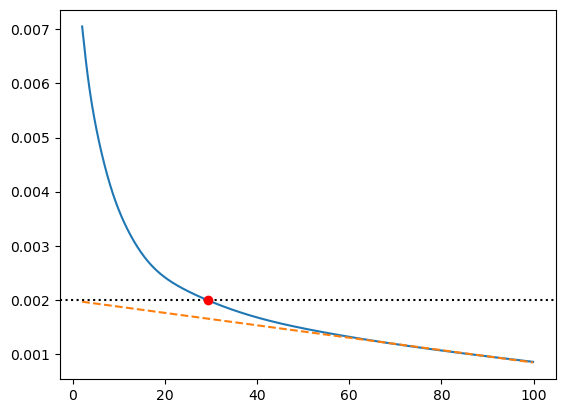

In [105]:
plt.figure()
plt.plot(frequencies, e)
plt.plot(frequencies, line(frequencies), '--')

plt.axhline(b, color='k', linestyle=':')
plt.plot(f_cross, rmse_cross, 'ro')